# Load and explore dataset

In [1]:
import pandas as pd

# Load the CSV file into a pandas DataFrame
# Replace 'your_file.csv' with the path to your CSV file
df = pd.read_csv(r"C:\Users\Adithya Ramachar\Desktop\Projects\Credit Risk Modelling\data\bank_churn_dataset.csv")

# Display the first 5 rows of the DataFrame to verify it loaded correctly
print(df.head())



   id         full_name  credit_sco  gender  age            occupation  \
0   1       Đặng Văn Vũ         725    male   55  Chủ Doanh nghiệp nhỏ   
1   2      Bùi Hữu Phúc         689    male   45     Nội trợ/Sinh viên   
2   3        Lê Văn Mai         702  female   44  Chủ Doanh nghiệp nhỏ   
3   4  Dương Trần Nhiên         766    male   44  Chủ Doanh nghiệp nhỏ   
4   5    Dương Thu Linh         677  female   77  Giáo viên/Giảng viên   

     balance  monthly_ir                 address  origin_province  ...  \
0  177306004   121000000      Phường An Hội (BT)  TP. Hồ Chí Minh  ...   
1    1927416     5000000   Phường Bến Thành (Q1)         Đồng Nai  ...   
2  304931745   109000000   Phường Hòa Bình (Q11)  TP. Hồ Chí Minh  ...   
3   50615501    79000000           Phường 7 (Q7)  TP. Hồ Chí Minh  ...   
4   40532432    25000000  Phường Thắng Lợi (Q10)  TP. Hồ Chí Minh  ...   

   last_transaction_month  created_date   exit  customer_segment  \
0                91038993    27/02/2025  F

In [2]:
# Get basic information about the DataFrame
print("\nDataFrame Info:")
print(df.info())



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      80000 non-null  int64  
 1   full_name               80000 non-null  object 
 2   credit_sco              80000 non-null  int64  
 3   gender                  80000 non-null  object 
 4   age                     80000 non-null  int64  
 5   occupation              80000 non-null  object 
 6   balance                 80000 non-null  int64  
 7   monthly_ir              80000 non-null  int64  
 8   address                 80000 non-null  object 
 9   origin_province         80000 non-null  object 
 10  tenure_ye               80000 non-null  int64  
 11  married                 80000 non-null  int64  
 12  nums_card               80000 non-null  int64  
 13  nums_service            80000 non-null  int64  
 14  active_member        

In [3]:

# Get basic statistics of the numerical columns
print("\nBasic Statistics:")
print(df.describe())


Basic Statistics:
                 id    credit_sco           age       balance    monthly_ir  \
count  80000.000000  80000.000000  80000.000000  8.000000e+04  8.000000e+04   
mean   40000.500000    684.321137     49.381862  6.118320e+07  3.778820e+07   
std    23094.155105     51.169733     15.067480  8.868620e+07  3.655107e+07   
min        1.000000    495.000000     20.000000  4.086630e+05  3.000000e+06   
25%    20000.750000    649.000000     38.000000  1.462592e+07  1.400000e+07   
50%    40000.500000    682.000000     47.000000  3.090276e+07  2.300000e+07   
75%    60000.250000    718.000000     58.000000  6.960994e+07  4.700000e+07   
max    80000.000000    800.000000     90.000000  1.000000e+09  2.160000e+08   

          tenure_ye       married     nums_card  nums_service  \
count  80000.000000  80000.000000  80000.000000  80000.000000   
mean       1.777250      0.970825      2.634688      3.564425   
std        1.315828      0.694698      1.218556      2.002448   
min      

In [4]:
df.isnull().sum()

id                        0
full_name                 0
credit_sco                0
gender                    0
age                       0
occupation                0
balance                   0
monthly_ir                0
address                   0
origin_province           0
tenure_ye                 0
married                   0
nums_card                 0
nums_service              0
active_member             0
last_active_date          0
last_transaction_month    0
created_date              0
exit                      0
customer_segment          0
engagement_score          0
loyalty_level             0
digital_behavior          0
risk_score                0
risk_segment              0
cluster_group             0
dtype: int64

## 1. Correlation Heatmap

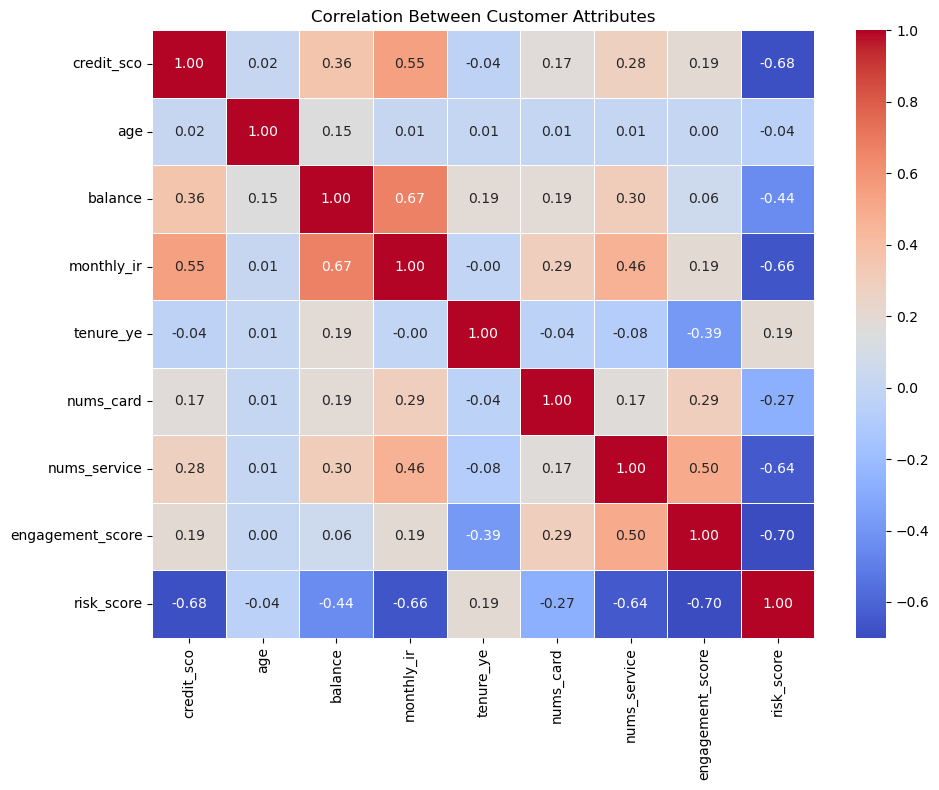

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
numerical_cols = ['credit_sco', 'age', 'balance', 'monthly_ir', 'tenure_ye', 
                 'nums_card', 'nums_service', 'engagement_score', 'risk_score']

# Create correlation matrix
corr_matrix = df[numerical_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Between Customer Attributes')
plt.tight_layout()
plt.show()

## 2. Customer Segmentation

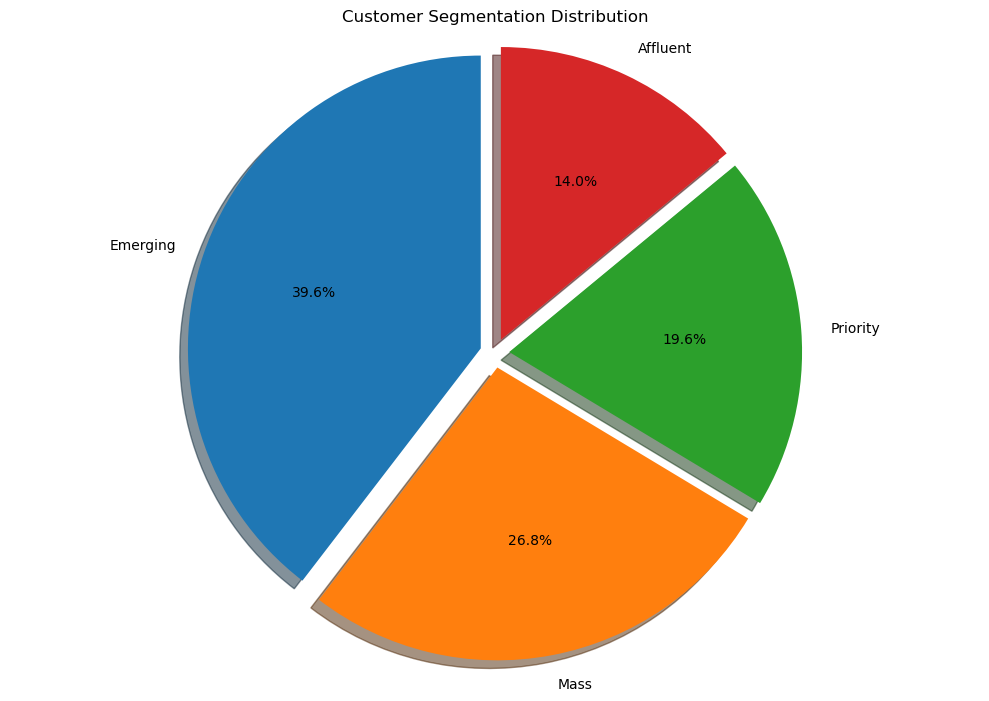

In [6]:
# Count customers in each segment
segment_counts = df['customer_segment'].value_counts()

# Create pie chart
plt.figure(figsize=(10, 7))
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', 
        startangle=90, shadow=True, explode=[0.05]*len(segment_counts))
plt.title('Customer Segmentation Distribution')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.tight_layout()
plt.show()

## 3. Age Distribution by Loyalty Level

C:\Users\Adithya Ramachar\AppData\Local\Temp\ipykernel_128484\2837125372.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loyalty_level', y='age', data=df, palette='viridis')


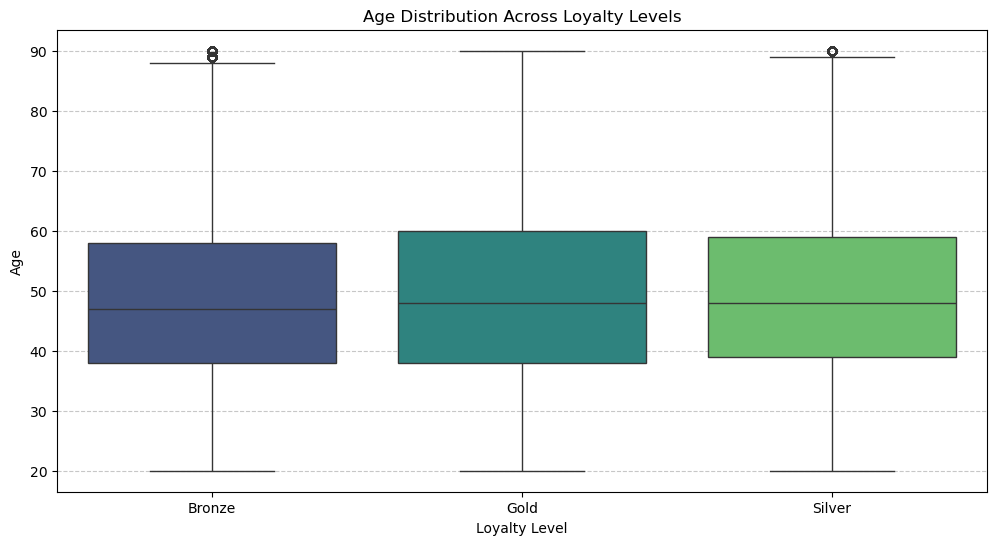

In [7]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='loyalty_level', y='age', data=df, palette='viridis')
plt.title('Age Distribution Across Loyalty Levels')
plt.xlabel('Loyalty Level')
plt.ylabel('Age')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 4. Risk Score vs. Balance Scatter Plot


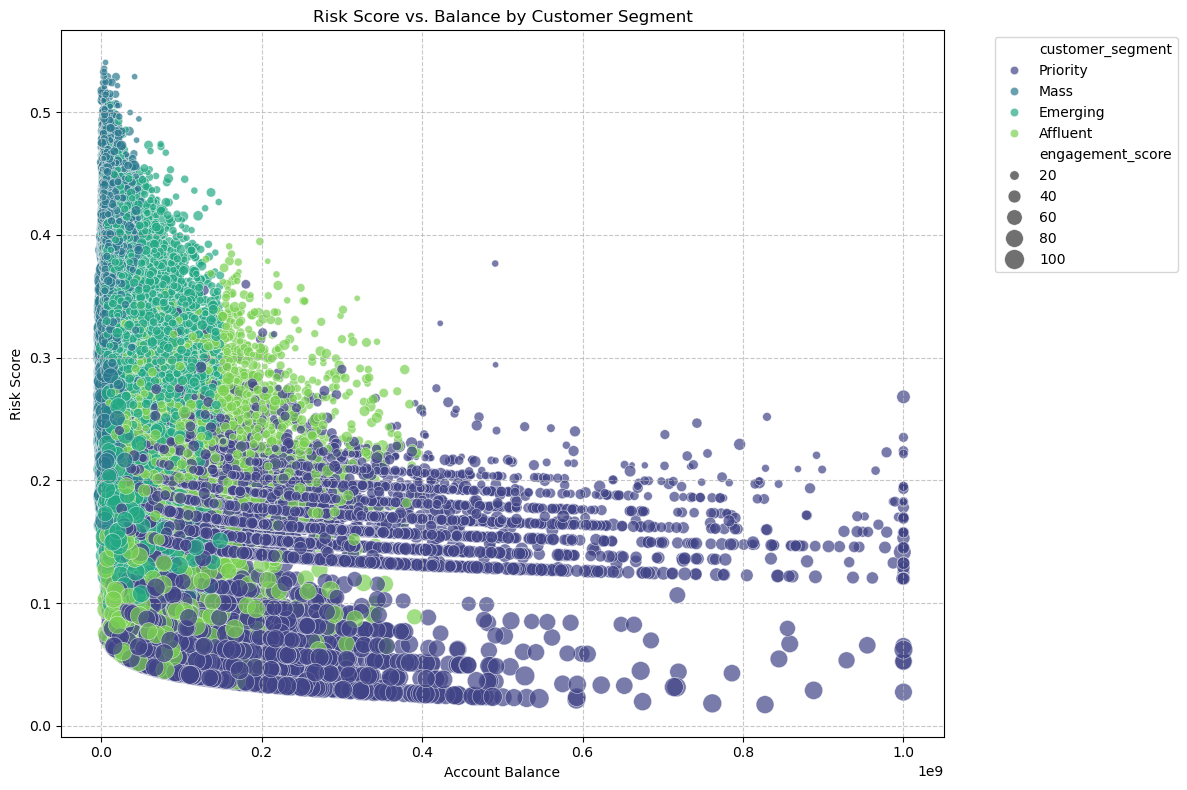

In [8]:
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(data=df, x='balance', y='risk_score', 
                         hue='customer_segment', palette='viridis', 
                         size='engagement_score', sizes=(20, 200), alpha=0.7)
plt.title('Risk Score vs. Balance by Customer Segment')
plt.xlabel('Account Balance')
plt.ylabel('Risk Score')
plt.grid(linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 5. Churn Analysis Bar Chart

## 5. Churn Analysis Bar Chart

C:\Users\Adithya Ramachar\AppData\Local\Temp\ipykernel_128484\2671556132.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=exit_by_occupation.index, y=exit_by_occupation.values, palette='rocket')


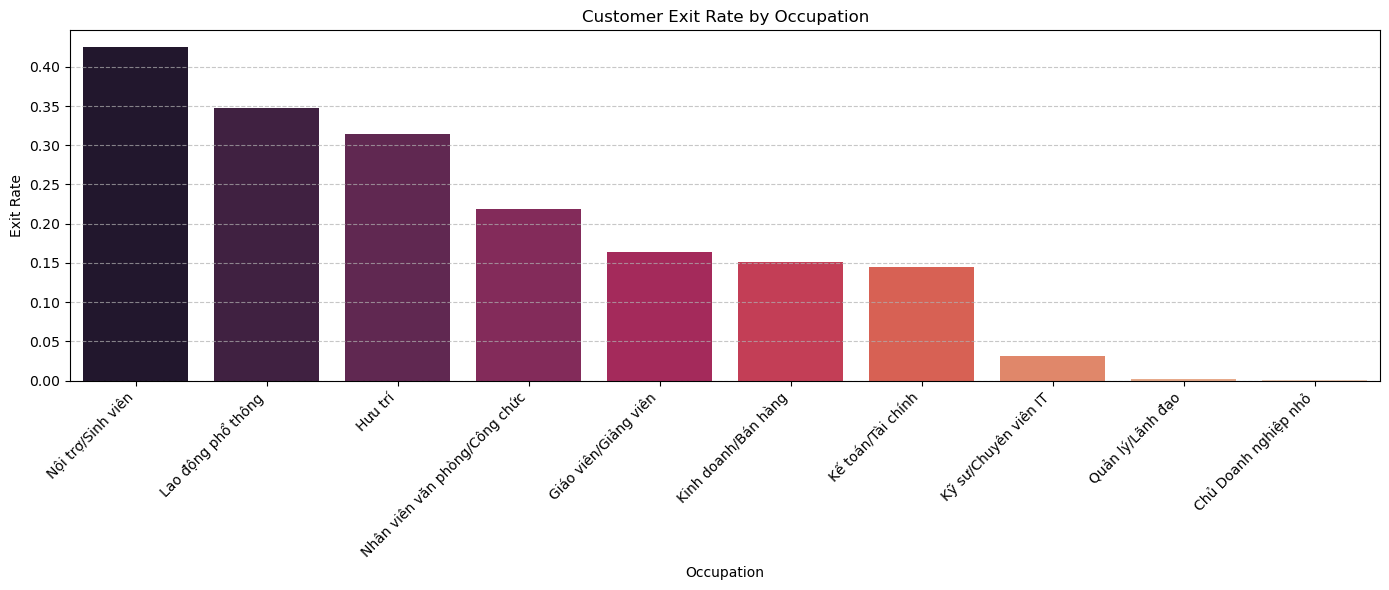

In [9]:
# Calculate exit rate by occupation
exit_by_occupation = df.groupby('occupation')['exit'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=exit_by_occupation.index, y=exit_by_occupation.values, palette='rocket')
plt.title('Customer Exit Rate by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Exit Rate')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\Adithya Ramachar\AppData\Local\Temp\ipykernel_128484\620483613.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=exit_by_loyalty.index, y=exit_by_loyalty.values, palette='rocket')


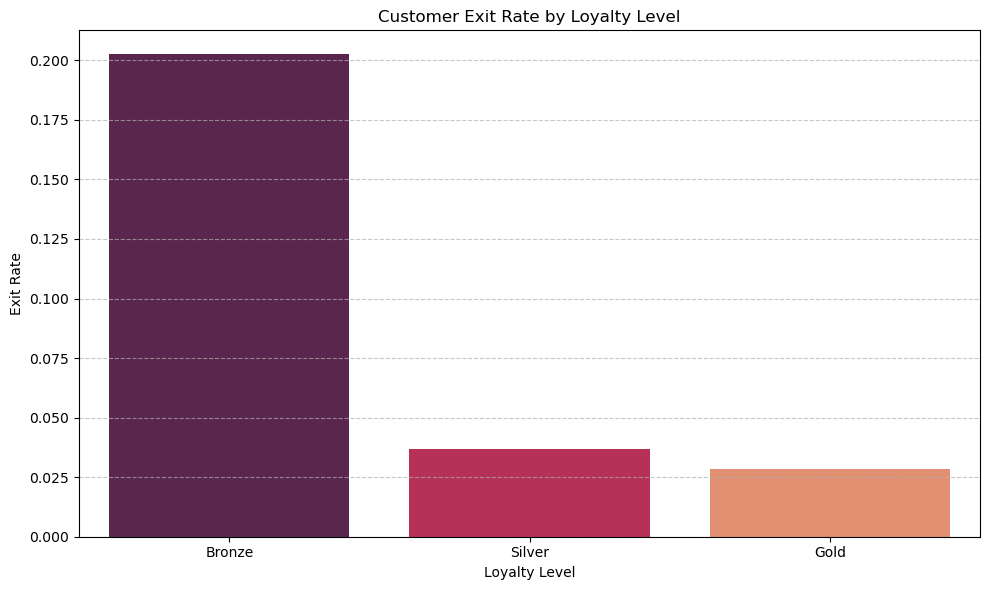

In [10]:
# Exit rate by loyalty level
exit_by_loyalty = df.groupby('loyalty_level')['exit'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=exit_by_loyalty.index, y=exit_by_loyalty.values, palette='rocket')
plt.title('Customer Exit Rate by Loyalty Level')
plt.xlabel('Loyalty Level')
plt.ylabel('Exit Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\Adithya Ramachar\AppData\Local\Temp\ipykernel_128484\1345181145.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=exit_by_loyalty.index, y=exit_by_loyalty.values, palette='rocket')


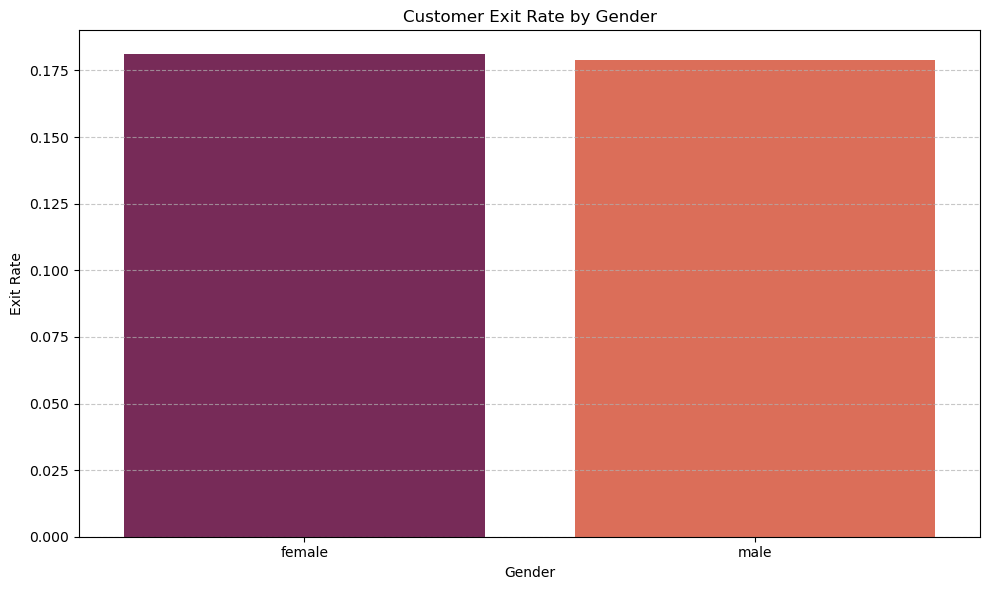

In [11]:
# Exit rate by Gender
exit_by_loyalty = df.groupby('gender')['exit'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=exit_by_loyalty.index, y=exit_by_loyalty.values, palette='rocket')
plt.title('Customer Exit Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Exit Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\Adithya Ramachar\AppData\Local\Temp\ipykernel_128484\904413490.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=exit_by_loyalty.index, y=exit_by_loyalty.values, palette='rocket')


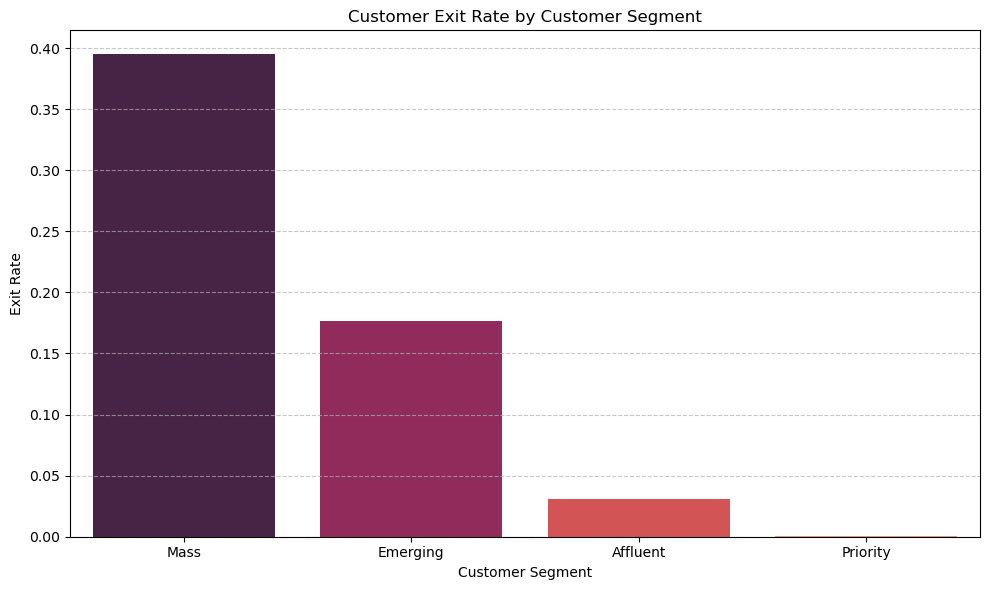

In [12]:
# Exit rate by customer segment
exit_by_loyalty = df.groupby('customer_segment')['exit'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=exit_by_loyalty.index, y=exit_by_loyalty.values, palette='rocket')
plt.title('Customer Exit Rate by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Exit Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\Adithya Ramachar\AppData\Local\Temp\ipykernel_128484\3104900575.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=exit_by_loyalty.index, y=exit_by_loyalty.values, palette='rocket')


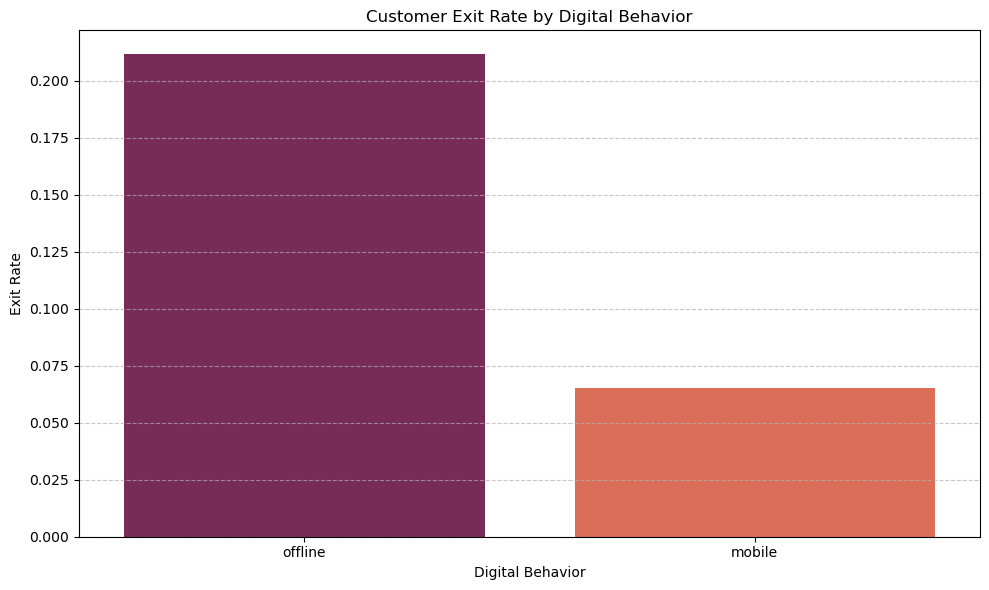

In [13]:
# Exit rate by customer segment
exit_by_loyalty = df.groupby('digital_behavior')['exit'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=exit_by_loyalty.index, y=exit_by_loyalty.values, palette='rocket')
plt.title('Customer Exit Rate by Digital Behavior')
plt.xlabel('Digital Behavior')
plt.ylabel('Exit Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\Adithya Ramachar\AppData\Local\Temp\ipykernel_128484\4238410835.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=exit_by_occupation.index, y=exit_by_occupation.values, palette='rocket', ax=axes[0])
C:\Users\Adithya Ramachar\AppData\Local\Temp\ipykernel_128484\4238410835.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=exit_by_loyalty.index, y=exit_by_loyalty.values, palette='rocket', ax=axes[1])
C:\Users\Adithya Ramachar\AppData\Local\Temp\ipykernel_128484\4238410835.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=

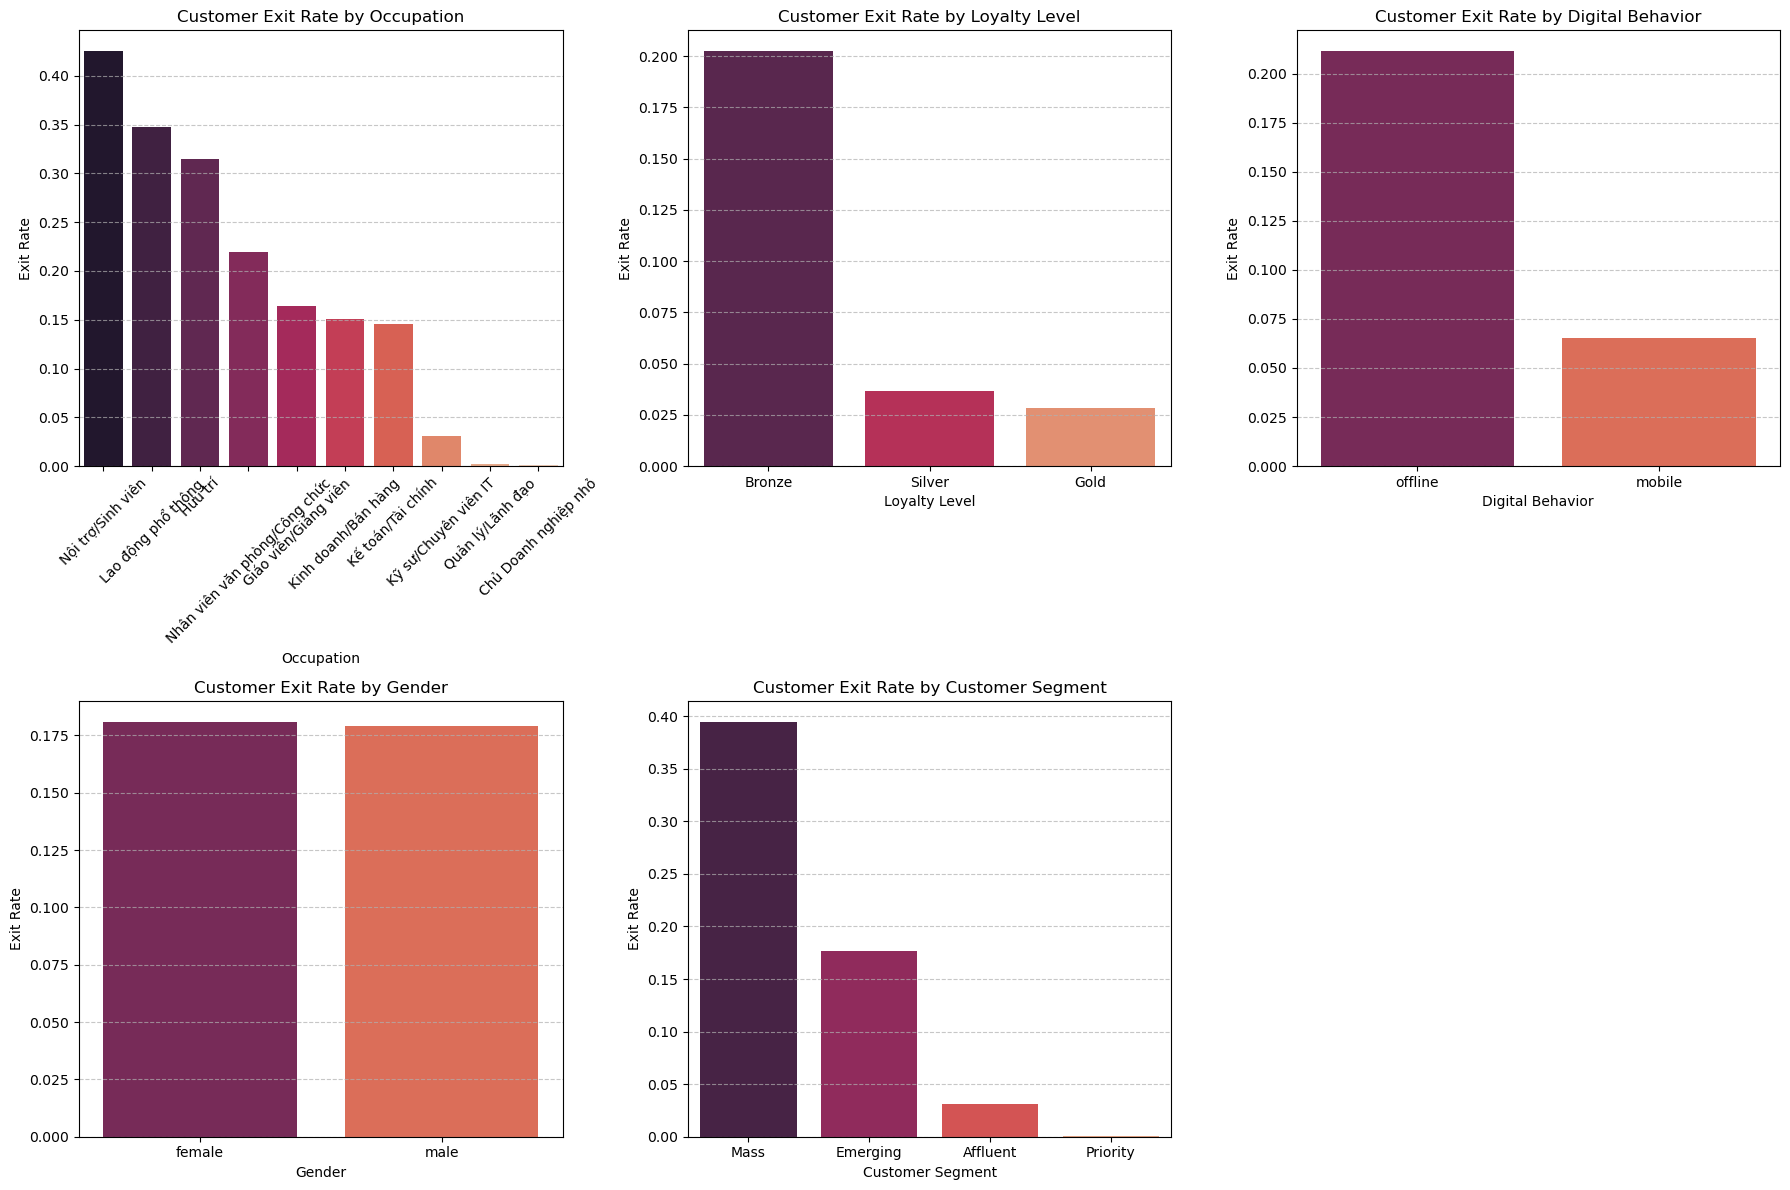

In [14]:
# Create a figure with 5 subplots arranged in 2 rows (3 in first row, 2 in second row)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))  # 2 rows, 3 columns

# Flatten the axes array to make it easier to access individual subplots
axes = axes.flatten()

# Subplot 1: Exit rate by Occupation
exit_by_occupation = df.groupby('occupation')['exit'].mean().sort_values(ascending=False)
sns.barplot(x=exit_by_occupation.index, y=exit_by_occupation.values, palette='rocket', ax=axes[0])
axes[0].set_title('Customer Exit Rate by Occupation')
axes[0].set_xlabel('Occupation')
axes[0].set_ylabel('Exit Rate')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Subplot 2: Exit rate by loyalty level
exit_by_loyalty = df.groupby('loyalty_level')['exit'].mean().sort_values(ascending=False)
sns.barplot(x=exit_by_loyalty.index, y=exit_by_loyalty.values, palette='rocket', ax=axes[1])
axes[1].set_title('Customer Exit Rate by Loyalty Level')
axes[1].set_xlabel('Loyalty Level')
axes[1].set_ylabel('Exit Rate')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Subplot 3: Exit rate by digital behaviour
exit_by_digital = df.groupby('digital_behavior')['exit'].mean().sort_values(ascending=False)
sns.barplot(x=exit_by_digital.index, y=exit_by_digital.values, palette='rocket', ax=axes[2])
axes[2].set_title('Customer Exit Rate by Digital Behavior')
axes[2].set_xlabel('Digital Behavior')
axes[2].set_ylabel('Exit Rate')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

# Subplot 4: Exit rate by gender
exit_by_gender = df.groupby('gender')['exit'].mean().sort_values(ascending=False)
sns.barplot(x=exit_by_gender.index, y=exit_by_gender.values, palette='rocket', ax=axes[3])
axes[3].set_title('Customer Exit Rate by Gender')
axes[3].set_xlabel('Gender')
axes[3].set_ylabel('Exit Rate')
axes[3].grid(axis='y', linestyle='--', alpha=0.7)

# Subplot 5: Exit rate by customer segment
exit_by_customer_segment = df.groupby('customer_segment')['exit'].mean().sort_values(ascending=False)
sns.barplot(x=exit_by_customer_segment.index, y=exit_by_customer_segment.values, palette='rocket', ax=axes[4])
axes[4].set_title('Customer Exit Rate by Customer Segment')
axes[4].set_xlabel('Customer Segment')
axes[4].set_ylabel('Exit Rate')
axes[4].grid(axis='y', linestyle='--', alpha=0.7)

# Hide the empty subplot (since we only need 5 out of 6 subplots)
axes[5].set_visible(False)

plt.tight_layout()
plt.show()

In [15]:
df.columns

Index(['id', 'full_name', 'credit_sco', 'gender', 'age', 'occupation',
       'balance', 'monthly_ir', 'address', 'origin_province', 'tenure_ye',
       'married', 'nums_card', 'nums_service', 'active_member',
       'last_active_date', 'last_transaction_month', 'created_date', 'exit',
       'customer_segment', 'engagement_score', 'loyalty_level',
       'digital_behavior', 'risk_score', 'risk_segment', 'cluster_group'],
      dtype='object')

# Feature Engineering

In [16]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
import re

# Assuming df is your dataframe with the columns listed
# If not, load your data first: df = pd.read_csv('your_data.csv')

# 1. Handle missing values first
numeric_cols = ['credit_sco', 'age', 'balance', 'monthly_ir', 'tenure_ye', 'nums_card', 
                'nums_service', 'engagement_score', 'risk_score']
categorical_cols = ['gender', 'occupation', 'origin_province', 'married', 'active_member', 
                   'customer_segment', 'loyalty_level', 'digital_behavior', 'risk_segment']

# Numeric imputation
num_imputer = SimpleImputer(strategy='median')
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

# Categorical imputation
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

# 2. Feature creation from existing columns

# Age-related features
df['age_group'] = pd.cut(df['age'], bins=[0, 18, 30, 45, 60, 100], 
                         labels=['Under 18', '18-30', '31-45', '46-60', 'Over 60'])

# Balance-related features
df['balance_per_tenure'] = df['balance'] / (df['tenure_ye'] + 1)  # Avoid division by zero
df['high_balance'] = (df['balance'] > df['balance'].median()).astype(int)

# Date features
date_cols = ['last_active_date', 'last_transaction_month', 'created_date']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

if 'created_date' in df.columns and 'last_active_date' in df.columns:
    # Customer lifetime in days
    df['customer_lifetime'] = (df['last_active_date'] - df['created_date']).dt.days
    
    # Days since last activity
    today = pd.to_datetime('today')
    df['days_since_last_active'] = (today - df['last_active_date']).dt.days

# 3. Extract information from address
if 'address' in df.columns:
    # Extract zip code (assuming US format)
    df['zip_code'] = df['address'].str.extract(r'(\d{5}(?:-\d{4})?)')
    
    # Flag if address contains keywords like 'Apt', 'Suite', etc.
    df['is_apartment'] = df['address'].str.contains(r'apt|suite|unit|#', case=False).astype(int)

# 4. Name features
if 'full_name' in df.columns:
    # Extract first name
    df['first_name'] = df['full_name'].str.split(' ').str[0]
    
    # Name length might correlate with certain demographics
    df['name_length'] = df['full_name'].str.len()

# 5. Service utilization features
df['service_card_ratio'] = df['nums_service'] / (df['nums_card'] + 1)  # Avoid division by zero
df['total_products'] = df['nums_service'] + df['nums_card']

# 6. Encode categorical variables
# One-hot encoding for categorical variables with few categories
# One-hot encoding for categorical variables with few categories
ohe_cols = ['gender', 'married', 'active_member', 'loyalty_level']
encoder = OneHotEncoder(sparse_output=False, drop='first')  # Changed 'sparse' to 'sparse_output'
encoded_features = encoder.fit_transform(df[ohe_cols])
encoded_df = pd.DataFrame(
    encoded_features, 
    columns=encoder.get_feature_names_out(ohe_cols),
    index=df.index
)
df = pd.concat([df, encoded_df], axis=1)

# Label encoding for ordinal categories or high-cardinality categoricals
le_cols = ['occupation', 'origin_province', 'customer_segment', 'digital_behavior', 'risk_segment']
for col in le_cols:
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))

# 7. Scale numeric features
scaler = StandardScaler()
df[numeric_cols + ['balance_per_tenure', 'customer_lifetime', 'days_since_last_active']] = scaler.fit_transform(
    df[numeric_cols + ['balance_per_tenure', 'customer_lifetime', 'days_since_last_active']].fillna(0)
)

# 8. Create interaction features
df['credit_balance_interaction'] = df['credit_sco'] * df['balance']
df['age_tenure_ratio'] = df['age'] / (df['tenure_ye'] + 1)

# 9. Risk-related features
df['high_risk'] = (df['risk_score'] > df['risk_score'].median()).astype(int)
df['risk_engagement_ratio'] = df['risk_score'] / (df['engagement_score'] + 1)

# 10. Drop original columns that are now encoded or no longer needed
# This step depends on your modeling needs - uncomment if appropriate
df = df.drop(ohe_cols + ['full_name', 'address'], axis=1)

# Display the shape of the transformed dataset
print(f"Original columns: {len(['id', 'full_name', 'credit_sco', 'gender', 'age', 'occupation', 'balance', 'monthly_ir', 'address', 'origin_province', 'tenure_ye', 'married', 'nums_card', 'nums_service', 'active_member', 'last_active_date', 'last_transaction_month', 'created_date', 'exit', 'customer_segment', 'engagement_score', 'loyalty_level', 'digital_behavior', 'risk_score', 'risk_segment'])}")
print(f"New dataset shape: {df.shape}")

C:\Users\Adithya Ramachar\AppData\Local\Temp\ipykernel_128484\2227631420.py:39: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors='coerce')


Original columns: 25
New dataset shape: (80000, 47)


In [17]:
df.head()

,id,credit_sco,age,occupation,balance,monthly_ir,origin_province,tenure_ye,nums_card,nums_service,...,loyalty_level_Silver,occupation_encoded,origin_province_encoded,customer_segment_encoded,digital_behavior_encoded,risk_segment_encoded,credit_balance_interaction,age_tenure_ratio,high_risk,risk_engagement_ratio
0,1,0.794984,0.372867,Chủ Doanh nghiệp nhỏ,1.309375,2.276604,TP. Hồ Chí Minh,-1.350679,1.120442,2.215090,...,0.0,0,5,3,0,0,1.040932,-1.063274,0,-0.729245
1,2,0.091439,-0.290818,Nội trợ/Sinh viên,-0.668155,-0.897057,Đồng Nai,0.929268,0.299793,-0.781261,...,0.0,8,8,2,0,0,-0.061095,-0.150740,0,-0.013345
2,3,0.345497,-0.357186,Chủ Doanh nghiệp nhỏ,2.748456,1.948295,TP. Hồ Chí Minh,1.689251,-0.520856,2.215090,...,1.0,0,5,3,1,0,0.949582,-0.132820,0,-1.242464
3,4,1.596244,-0.357186,Chủ Doanh nghiệp nhỏ,-0.119159,1.127520,TP. Hồ Chí Minh,0.929268,1.120442,-0.281869,...,0.0,0,5,3,1,0,-0.190207,-0.185141,0,-0.879186
4,5,-0.143076,1.832975,Giáo viên/Giảng viên,-0.232854,-0.349874,TP. Hồ Chí Minh,0.169286,1.120442,-0.281869,...,0.0,1,5,1,1,0,0.033316,1.567602,1,0.431971


In [18]:
df.columns

Index(['id', 'credit_sco', 'age', 'occupation', 'balance', 'monthly_ir',
       'origin_province', 'tenure_ye', 'nums_card', 'nums_service',
       'last_active_date', 'last_transaction_month', 'created_date', 'exit',
       'customer_segment', 'engagement_score', 'digital_behavior',
       'risk_score', 'risk_segment', 'cluster_group', 'age_group',
       'balance_per_tenure', 'high_balance', 'customer_lifetime',
       'days_since_last_active', 'zip_code', 'is_apartment', 'first_name',
       'name_length', 'service_card_ratio', 'total_products', 'gender_male',
       'married_1', 'married_2', 'married_3', 'active_member_True',
       'loyalty_level_Gold', 'loyalty_level_Silver', 'occupation_encoded',
       'origin_province_encoded', 'customer_segment_encoded',
       'digital_behavior_encoded', 'risk_segment_encoded',
       'credit_balance_interaction', 'age_tenure_ratio', 'high_risk',
       'risk_engagement_ratio'],
      dtype='object')

# Churn Prediction

## 1. Logistic Regression

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.feature_selection import RFE

# Assuming df is your dataframe with all the columns listed
# First, let's identify the target variable (churn indicator)
target = 'exit'  # Assuming 'exit' is the churn indicator (1 = churned, 0 = not churned)

# Remove non-predictive columns
cols_to_drop = ['id', 'last_active_date', 'last_transaction_month', 'created_date', 
                'first_name', 'zip_code', 'name_length']

# Also remove duplicate columns (gender_male, married_1, etc. appear twice in your list)
# And remove any columns that might cause data leakage
features = df.drop(cols_to_drop + [target], axis=1).columns.tolist()

# Remove duplicates from features list
features = list(dict.fromkeys(features))

# Split the data
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Feature selection using Recursive Feature Elimination
# This helps identify the most important features for our model
rfe = RFE(estimator=LogisticRegression(max_iter=1000, random_state=42), n_features_to_select=15)
rfe.fit(X_train_scaled, y_train)
selected_features = [features[i] for i in range(len(features)) if rfe.support_[i]]
print(f"Selected features: {selected_features}")

# Get indices of selected features
selected_indices = [i for i in range(len(features)) if rfe.support_[i]]
X_train_selected = X_train_scaled[:, selected_indices]
X_test_selected = X_test_scaled[:, selected_indices]

# Build the logistic regression model
model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model.fit(X_train_selected, y_train)

# Evaluate the model
y_pred = model.predict(X_test_selected)
y_pred_proba = model.predict_proba(X_test_selected)[:, 1]

# Print model performance
print("\nModel Performance:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Feature importance
coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': model.coef_[0],
    'Abs_Coefficient': np.abs(model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("\nFeature Importance:")
print(coef_df)

# Visualize feature importance
plt.figure(figsize=(10, 8))
sns.barplot(x='Coefficient', y='Feature', data=coef_df)
plt.title('Feature Importance for Churn Prediction')
plt.axvline(x=0, color='k', linestyle='--')
plt.tight_layout()
plt.show()

# Cross-validation to ensure model stability
cv_scores = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='roc_auc')
print(f"\nCross-validation ROC AUC scores: {cv_scores}")
print(f"Mean CV ROC AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

ValueError: could not convert string to float: 'Quản lý/Lãnh đạo'

In [20]:
df[features].dtypes

credit_sco                     float64
age                            float64
occupation                      object
balance                        float64
monthly_ir                     float64
origin_province                 object
tenure_ye                      float64
nums_card                      float64
nums_service                   float64
customer_segment                object
engagement_score               float64
digital_behavior                object
risk_score                     float64
risk_segment                    object
cluster_group                    int64
age_group                     category
balance_per_tenure             float64
high_balance                     int64
customer_lifetime              float64
days_since_last_active         float64
is_apartment                     int64
service_card_ratio             float64
total_products                 float64
gender_male                    float64
married_1                      float64
married_2                

In [23]:
df[['occupation', 'origin_province', 'customer_segment', 'risk_segment', 'digital_behavior']]

,occupation,origin_province,customer_segment,risk_segment,digital_behavior
0,Chủ Doanh nghiệp nhỏ,TP. Hồ Chí Minh,Priority,Low,mobile
1,Nội trợ/Sinh viên,Đồng Nai,Mass,Low,mobile
2,Chủ Doanh nghiệp nhỏ,TP. Hồ Chí Minh,Priority,Low,offline
3,Chủ Doanh nghiệp nhỏ,TP. Hồ Chí Minh,Priority,Low,offline
4,Giáo viên/Giảng viên,TP. Hồ Chí Minh,Emerging,Low,offline
...,...,...,...,...,...
79995,Nhân viên văn phòng/Công chức,TP. Hồ Chí Minh,Affluent,Low,offline
79996,Nhân viên văn phòng/Công chức,Đồng Nai,Affluent,Low,offline
79997,Kinh doanh/Bán hàng,TP. Hồ Chí Minh,Emerging,Low,mobile
79998,Nội trợ/Sinh viên,TP. Hồ Chí Minh,Emerging,Low,offline
